In [1]:
%pip install -e .
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

from agents.Job_ranker import start_career_optimization
from services.parser.pdf_reader_n_clearner import pdf_reader
from agents.Career_Path_Agent import generate_career_suggestions
from services.scraper.Job_scraper import fetch_jobs
from agents.Resume_extraction_agent import Resume_extaction
from agents.resume_rewrite_agent import resume_rewrite
from agents.suggested_Job_formating import suggested_Job_formating
from agents.human_rewritter_agent import human_rewritter_agent
from core.Nodes.Conditions import ingestion_condition, skill_extraction_condition, job_search_condition, critic_resume_rewrite_condition
from core.Nodes.GraphState import GraphState
from langgraph.graph import StateGraph,START,END

graph = StateGraph(GraphState)

Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///C:/Users/USER/Documents/Projects/Main%20projects/AI%20Career%20Optimization%20System/core/Nodes
Note: you may need to restart the kernel to use updated packages.


ERROR: file:///C:/Users/USER/Documents/Projects/Main%20projects/AI%20Career%20Optimization%20System/core/Nodes does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Yaml file loaded successfully.
Yaml file loaded successfully.
--- Loading Resume_extraction_agent.py ---
Yaml file loaded successfully.
Yaml file loaded successfully.
Yaml file loaded successfully.
Yaml file loaded successfully.
Yaml file loaded successfully.
Yaml file loaded successfully.
Yaml file loaded successfully.
Yaml file loaded successfully.


In [ ]:
graph.add_node('pdf_reader', pdf_reader)
graph.add_node('Resume_extaction',Resume_extaction)
graph.add_node('fetch_jobs',fetch_jobs)
graph.add_node('start_career_optimization',start_career_optimization)
graph.add_node('suggested_Job_formating',suggested_Job_formating)
graph.add_node('resume_rewrite',resume_rewrite)
graph.add_node('human_rewritter_agent',human_rewritter_agent)

graph.add_edge(START, 'pdf_reader')
graph.add_edge('pdf_reader', 'Resume_extaction')

graph.add_conditional_edges('Resume_extaction', ingestion_condition, {
    "passed": 'suggested_Job_formating',
    "retry": 'Resume_extaction',
    "failed": END
})

graph.add_conditional_edges('suggested_Job_formating', skill_extraction_condition, {
    "passed": 'fetch_jobs', 
    "retry": 'suggested_Job_formating',
    "failed": END
})

graph.add_conditional_edges('suggested_Job_formating',job_search_condition,{
    "passed": 'fetch_jobs',
    "retry": 'suggested_Job_formating'

    # how do we pass in the feedback from the job search condition to the suggested job formatting agent to suggest new the job search results ?
})

graph.add_conditional_edges('fetch_jobs',critic_resume_rewrite_condition,{
    "Procced": 'resume_rewrite',
    "retry": 'fetch_jobs'

    # how do we pass in the feedback from the critic condition to the resume rewrite agent to improve the resume rewrite results ?
})

graph.add_edge('resume_rewrite','human_rewritter_agent')


graph.add_edge('human_rewritter_agent',END)

app = graph.compile()

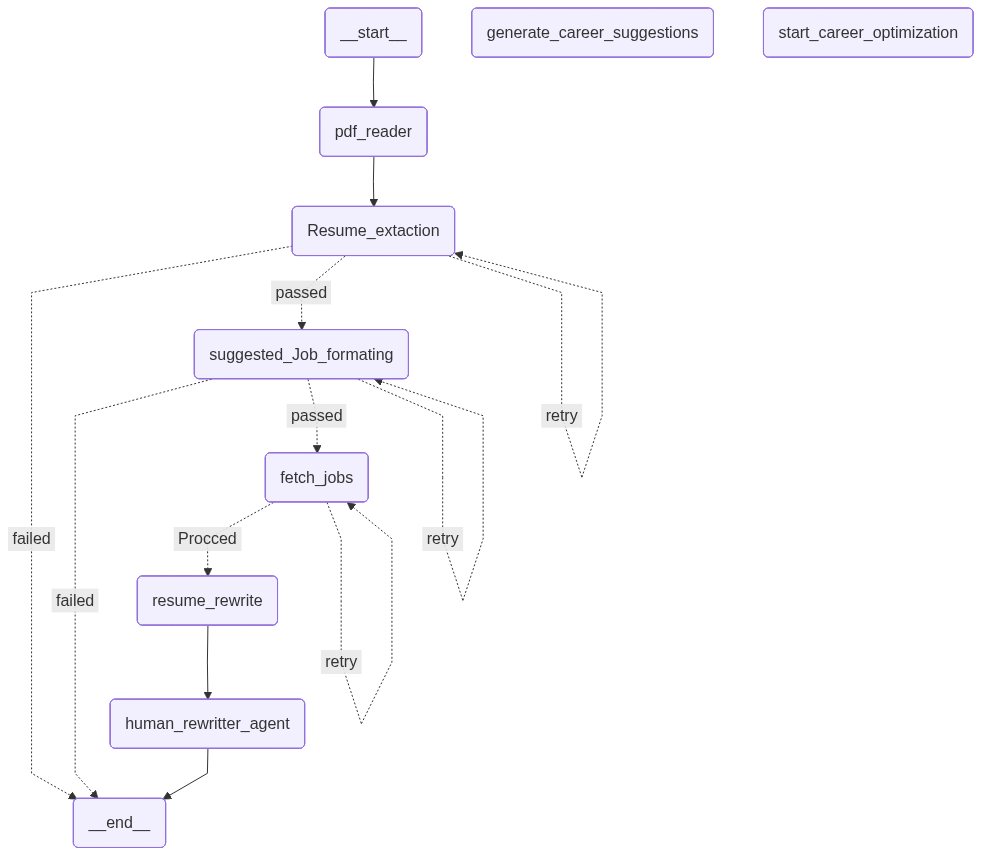

In [3]:
# Visualize the graph
from IPython.display import Image, display

# Get the graph visualization
graph_image = app.get_graph().draw_mermaid_png()
display(Image(graph_image))